
Pump Runtime Model
R2: 0.9999999709059756
MAE: 1.3434022263167848e-05
RMSE: 0.00016595103382569163

Next Irrigation Model
R2: 0.9944695120019371
MAE: 0.10795088608772536
RMSE: 1.5898980509981897


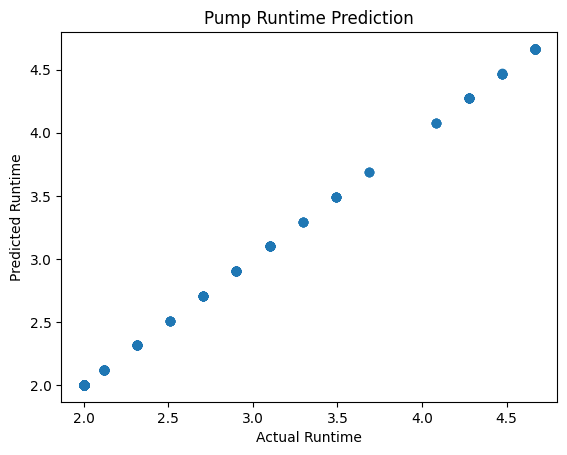

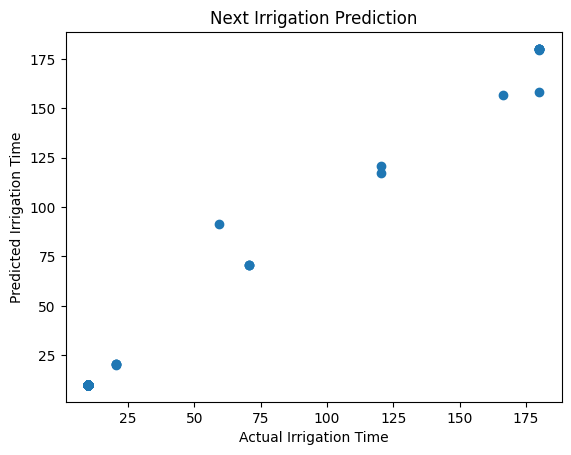

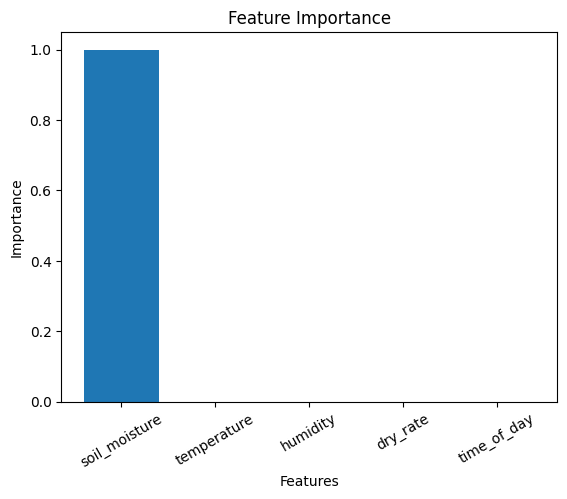


models saved


In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv("feeds.csv")

df = df.rename(columns={
    "field1":"soil_moisture",
    "field2":"temperature",
    "field3":"humidity",
    "field4":"pump_runtime",
    "field5":"fan_state",
    "field6":"dry_rate"
})

df["created_at"] = pd.to_datetime(df["created_at"])

df["hour"] = df["created_at"].dt.hour
df["minute"] = df["created_at"].dt.minute

df["time_of_day"] = df["hour"] + df["minute"]/60

df["fan_state"] = (df["humidity"] >= 45).astype(int)
df["dry_rate"] = df["dry_rate"] * 0.02
SOIL_THRESHOLD = 32

def irrigation_delay(row):

    m = row["soil_moisture"]
    d = row["dry_rate"]

    if m <= SOIL_THRESHOLD:
        return 0

    if d <= 0:
        return 5

    return (m - SOIL_THRESHOLD) / d

df["next_irrigation_minutes"] = df.apply(irrigation_delay, axis=1)

# df["next_irrigation_minutes"] = df["next_irrigation_minutes"].clip(1,180)
df["next_irrigation_minutes"] = df["next_irrigation_minutes"].clip(10,180)
def pump_runtime(m):

    deficit = max(0, SOIL_THRESHOLD - m)

    runtime = 2 + deficit * 0.5

    return min(runtime,5)

df["pump_runtime"] = df["soil_moisture"].apply(pump_runtime)

features = [
    "soil_moisture",
    "temperature",
    "humidity",
    "dry_rate",
    "time_of_day"
]

X = df[features]

y_runtime = df["pump_runtime"]
y_next = df["next_irrigation_minutes"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train,X_test,y_run_train,y_run_test = train_test_split(
    X_scaled,y_runtime,test_size=0.2,random_state=42
)

_,_,y_next_train,y_next_test = train_test_split(
    X_scaled,y_next,test_size=0.2,random_state=42
)

runtime_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

time_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

runtime_model.fit(X_train,y_run_train)
time_model.fit(X_train,y_next_train)

runtime_pred = runtime_model.predict(X_test)
time_pred = time_model.predict(X_test)

print("\nPump Runtime Model")
print("R2:",r2_score(y_run_test,runtime_pred))
print("MAE:",mean_absolute_error(y_run_test,runtime_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_run_test,runtime_pred)))

print("\nNext Irrigation Model")
print("R2:",r2_score(y_next_test,time_pred))
print("MAE:",mean_absolute_error(y_next_test,time_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_next_test,time_pred)))

plt.figure()
plt.scatter(y_run_test,runtime_pred)
plt.xlabel("Actual Runtime")
plt.ylabel("Predicted Runtime")
plt.title("Pump Runtime Prediction")
plt.show()

plt.figure()
plt.scatter(y_next_test,time_pred)
plt.xlabel("Actual Irrigation Time")
plt.ylabel("Predicted Irrigation Time")
plt.title("Next Irrigation Prediction")
plt.show()

importance = runtime_model.feature_importances_

plt.figure()
plt.bar(features,importance)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=30)
plt.show()

joblib.dump(runtime_model,"pump_runtime_model.pkl")
joblib.dump(time_model,"next_irrigation_model.pkl")
joblib.dump(scaler,"irrigation_scaler.pkl")

print("\nmodels saved")

In [ ]:
import joblib
import numpy as np

# -------------------------
# LOAD MODELS
# -------------------------

runtime_model = joblib.load("/content/pump_runtime_model.pkl")
time_model = joblib.load("/content/next_irrigation_model.pkl")
scaler = joblib.load("/content/irrigation_scaler.pkl")

# -------------------------
# SAMPLE SENSOR DATA
# -------------------------

samples = [
    [30, 29, 50, 0.3, 14.5],   # soil, temp, humidity, dry_rate, time_of_day
    [35, 28, 40, 0.2, 10.2],
    [27, 31, 55, 0.4, 16.7],
    [33, 30, 42, 0.25, 12.0]
]

# -------------------------
# SCALE INPUT
# -------------------------

samples_scaled = scaler.transform(samples)

# -------------------------
# PREDICTIONS
# -------------------------

runtime_pred = runtime_model.predict(samples_scaled)
time_pred = time_model.predict(samples_scaled)

# -------------------------
# DISPLAY RESULTS
# -------------------------

for i, sample in enumerate(samples):

    soil, temp, hum, dry, tod = sample

    pump_runtime = runtime_pred[i]

    water_ml = pump_runtime * 3.75

    fan_state = 1 if hum >= 45 else 0

    print("\nSample", i+1)
    print("---------------------")
    print("Soil Moisture:", soil)
    print("Temperature:", temp)
    print("Humidity:", hum)

    print("Predicted Pump Runtime:", round(pump_runtime,2), "seconds")
    print("Water Required:", round(water_ml,2), "ml")

    print("Next Irrigation in:", round(time_pred[i],1), "minutes")

    print("Fan State:", "ON" if fan_state else "OFF")


Sample 1
---------------------
Soil Moisture: 30
Temperature: 29
Humidity: 50
Predicted Pump Runtime: 3.1 seconds
Water Required: 11.63 ml
Next Irrigation in: 10.0 minutes
Fan State: ON

Sample 2
---------------------
Soil Moisture: 35
Temperature: 28
Humidity: 40
Predicted Pump Runtime: 2.0 seconds
Water Required: 7.5 ml
Next Irrigation in: 106.3 minutes
Fan State: OFF

Sample 3
---------------------
Soil Moisture: 27
Temperature: 31
Humidity: 55
Predicted Pump Runtime: 4.47 seconds
Water Required: 16.76 ml
Next Irrigation in: 10.0 minutes
Fan State: ON

Sample 4
---------------------
Soil Moisture: 33
Temperature: 30
Humidity: 42
Predicted Pump Runtime: 2.0 seconds
Water Required: 7.5 ml
Next Irrigation in: 92.5 minutes
Fan State: OFF


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd


df = pd.read_csv("feeds.csv")
print("\n📊 Dataset Shape:", df.shape)
print("Rows (samples):", df.shape[0])
print("Columns (features):", df.shape[1])


📊 Dataset Shape: (3144, 12)
Rows (samples): 3144
Columns (features): 12
